# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw01/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

rng = np.random.default_rng(2026)

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Ответ:** Переменная $x=(x_1,x_2,x_3)^\top\in\mathbb R^3$ — искомая точка. Вместо расстояния минимизируем его квадрат: это не меняет точку минимума. Стандартная форма:

$$
\min_{x\in\mathbb R^3} f(x),\qquad
f(x)=(x_1-1)^2+(x_2-2)^2+(x_3-3)^2,
$$
$$
g(x)=\begin{pmatrix}x_1+x_2+x_3-1\\x_1-x_3\end{pmatrix}=0,
\qquad h\text{ отсутствует}.
$$

Это **выпуклая QP с ограничениями**: целевая функция квадратичная, $\nabla^2 f=2I_3\succ0$, а ограничения аффинные. Строгая выпуклость гарантирует единственность решения на непустом допустимом множестве.

Параметризуем прямую: $x=(s,1-2s,s)^\top$. Тогда

$$
f(s)=6s^2-4s+11,\qquad f'(s)=12s-4=0
\quad\Longrightarrow\quad s^*=\frac13.
$$

Следовательно, ближайшая точка и расстояние до неё равны

$$
x^*=\left(\frac13,\frac13,\frac13\right)^\top,
\qquad f(x^*)=\frac{31}{3},\qquad
\operatorname{dist}=\sqrt{\frac{31}{3}}.
$$

In [2]:
point = np.array([1.0, 2.0, 3.0])
line_origin = np.array([0.0, 1.0, 0.0])
line_direction = np.array([1.0, -2.0, 1.0])
s_opt = np.dot(line_direction, point - line_origin) / np.dot(line_direction, line_direction)
closest_point = line_origin + s_opt * line_direction

print("Ближайшая точка:", closest_point)
print(f"Квадрат расстояния: {np.sum((closest_point - point) ** 2):.10f}")
print(f"Расстояние: {np.linalg.norm(closest_point - point):.10f}")

Ближайшая точка: [0.33333333 0.33333333 0.33333333]
Квадрат расстояния: 10.3333333333
Расстояние: 3.2145502537


**(б)**

**Ответ:** Пусть $x=(x_1,\ldots,x_n)^\top\in\mathbb R^n$, где $x_j$ — количество продукта $j$ (допускаются дробные количества). При $c\in\mathbb R^n$, $A\in\mathbb R^{m\times n}$, $b\in\mathbb R^m$ стандартная форма имеет вид

$$
\min_{x\in\mathbb R^n} f(x),\qquad f(x)=c^\top x,
\qquad g\text{ отсутствует},\qquad
h(x)=\begin{pmatrix}Ax-b\\x\end{pmatrix}\ge0.
$$

Первые $m$ неравенств обеспечивают минимальное содержание питательных веществ, оставшиеся $n$ запрещают отрицательные количества продуктов. Это **выпуклая LP с ограничениями**: целевая функция линейная, все ограничения аффинные, допустимое множество — пересечение полупространств.

**(в)**

**Ответ:** Центр прямоугольника, все четыре вершины которого лежат на единичной окружности, совпадает с её центром: центр описанной окружности прямоугольника — точка пересечения его диагоналей. Поэтому обозначим через $x=(u,v)^\top\in\mathbb R^2$ половины длин сторон; вершины имеют координаты $(\pm u,\pm v)$, а площадь равна $4uv$.

Стандартная форма для вписанного прямоугольника:

$$
\min_{x\in\mathbb R^2} f(x),\qquad f(x)=-4uv,
\qquad g(x)=u^2+v^2-1=0,
\qquad h(x)=\begin{pmatrix}u\\v\end{pmatrix}\ge0.
$$

Это **невыпуклая QCQP с ограничениями**: целевая функция и равенство квадратичные. Допустимое множество — дуга окружности в первой четверти, оно невыпукло; кроме того,

$$
\nabla^2 f=\begin{pmatrix}0&-4\\-4&0\end{pmatrix}
$$

имеет собственные значения $-4$ и $4$, поэтому целевая функция не выпукла. Нулевые стороны разрешены как вырожденные случаи и не влияют на максимум.

Если понимать условие как размещение прямоугольника внутри круга, можно заменить равенство на $1-u^2-v^2\ge0$: оптимум будет тем же и достигнется на окружности. Эта постановка также является невыпуклой QCQP из-за целевой функции, хотя её допустимое множество выпукло.

Из $2uv\le u^2+v^2=1$ следует $4uv\le2$, причём равенство достигается при $u=v=1/\sqrt2$. Таким образом, оптимальный прямоугольник — квадрат со стороной $\sqrt2$ и площадью $2$.

**(г)**

**Ответ:** Параметры модели образуют вектор $x=(x_1,x_2,x_3)^\top\in\mathbb R^3$: амплитуда, частота и фаза соответственно. Стандартная форма:

$$
\min_{x\in\mathbb R^3} f(x),\qquad
f(x)=\sum_{i=1}^{N}\left(x_1\sin(x_2t_i+x_3)-y_i\right)^2,
\qquad g,h\text{ отсутствуют}.
$$

Это **невыпуклая NLP без ограничений**, задача нелинейных наименьших квадратов. Сумма квадратов не делает функцию квадратичной по параметрам: $x_2$ и $x_3$ входят в аргумент синуса. Невыпуклость можно увидеть на прямой $x_1=1$, $x_2=0$: при $N\ge1$ функция $\sum_i(\sin x_3-y_i)^2$ непостоянна и периодична, а такая функция не может быть выпуклой на всей $\mathbb R$. При фиксированных частоте и фазе задача по одной амплитуде была бы выпуклой квадратичной.

**(д, бонус)**

**Ответ:** Пусть имеется $m\ge1$ невязок, $a_i\in\mathbb R^n$, $b_i\in\mathbb R$. Введём дополнительную переменную $\tau\in\mathbb R$, ограничивающую сверху модули всех невязок. Новая переменная $z=(x^\top,\tau)^\top\in\mathbb R^{n+1}$, и стандартная форма такова:

$$
\min_{z\in\mathbb R^{n+1}} f(z),\qquad f(z)=\tau,
\qquad g\text{ отсутствует},
$$
$$
h(z)=
\begin{pmatrix}
\tau-a_1^\top x+b_1\\
\vdots\\
\tau-a_m^\top x+b_m\\
\tau+a_1^\top x-b_1\\
\vdots\\
\tau+a_m^\top x-b_m
\end{pmatrix}\ge0.
$$

Для каждого $i$ эти две границы эквивалентны $-\tau\le a_i^\top x-b_i\le\tau$, то есть $|a_i^\top x-b_i|\le\tau$. Поэтому при фиксированном $x$ наименьшее допустимое $\tau$ равно $\max_i|a_i^\top x-b_i|$, что доказывает эквивалентность задач. Условие $\tau\ge0$ уже следует из записанных неравенств.

Получилась **выпуклая LP с ограничениями**: целевая функция и все ограничения аффинны и, в частности, гладкие.

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

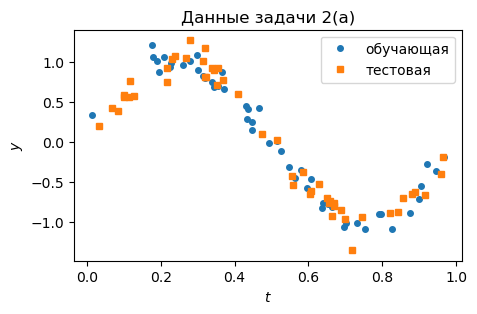

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

Степень    MSE обучения       MSE теста
      1      0.15146930      0.22579907
      2      0.13912302      0.26207708
      3      0.01068994      0.03152785
      4      0.00993289      0.03188009
      5      0.00946437      0.02597343
      6      0.00902997      0.03474452
      7      0.00900003      0.03995175
      8      0.00889650      0.06567351
      9      0.00888732      0.08323346
     10      0.00803788      0.89422301
     11      0.00798787      1.67885615
     12      0.00798108      2.40983052
     13      0.00685684     85.70723262
     14      0.00646100      1.25006688
     15      0.00607706    336.49369498

Минимальная тестовая MSE: 0.02597343 при d = 5


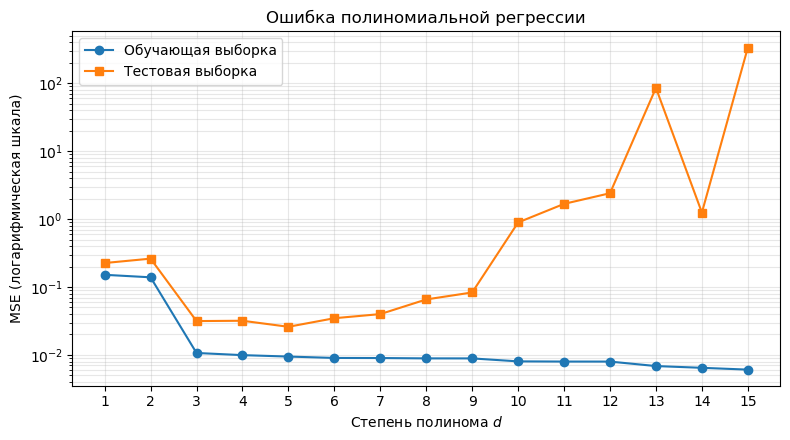

In [4]:
degrees = np.arange(1, 16)
train_mse = np.empty(degrees.size)
test_mse = np.empty(degrees.size)

for index, degree in enumerate(degrees):
    design_train = np.vander(t_train, degree + 1, increasing=True)
    design_test = np.vander(t_test, degree + 1, increasing=True)
    coefficients, _, _, _ = np.linalg.lstsq(design_train, y_train, rcond=None)
    train_mse[index] = np.mean((design_train @ coefficients - y_train) ** 2)
    test_mse[index] = np.mean((design_test @ coefficients - y_test) ** 2)

print(f"{'Степень':>7} {'MSE обучения':>15} {'MSE теста':>15}")
for degree, error_train, error_test in zip(degrees, train_mse, test_mse):
    print(f"{degree:7d} {error_train:15.8f} {error_test:15.8f}")

best_index = np.argmin(test_mse)
print(f"\nМинимальная тестовая MSE: {test_mse[best_index]:.8f} при d = {degrees[best_index]}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(degrees, train_mse, "o-", label="Обучающая выборка")
ax.semilogy(degrees, test_mse, "s-", label="Тестовая выборка")
ax.set_xticks(degrees)
ax.set_xlabel("Степень полинома $d$")
ax.set_ylabel("MSE (логарифмическая шкала)")
ax.set_title("Ошибка полиномиальной регрессии")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

**Ответ:** Использована ошибка $\mathrm{MSE}=\frac1N\sum_{i=1}^N(\varphi(t_i;x)-y_i)^2$; её минимум на обучающей выборке не возрастает при увеличении $d$, поскольку пространство полиномов степени не выше $d$ вложено в пространство степени не выше $d+1$ (в вычислениях это верно с учётом погрешности округления). Тестовая ошибка не обязана быть монотонной, так как минимизируется только обучающая: сначала более гибкая модель лучше описывает синус, а при больших степенях подстраивается под шум и становится неустойчивой между обучающими точками и у краёв интервала. В данной реализации минимальная тестовая MSE достигается при $d=5$ и составляет примерно $0.02597343$, а при $d=15$ обучающая MSE снижается до $0.00607706$, тогда как тестовая возрастает примерно до $336.49$, что показывает сильное переобучение.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [5]:
c = np.array([2.0, 3.0, 1.5, 4.0])
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])
b = np.array([10.0, 8.0, 12.0])

In [6]:
tolerance = 1e-9

def solve_diet(requirements):
    result = linprog(c, A_ub=-A, b_ub=-requirements, bounds=(0, None), method="highs")
    if not result.success:
        raise RuntimeError(result.message)
    nutrient_slack = A @ result.x - requirements
    if np.any(nutrient_slack < -tolerance) or np.any(result.x < -tolerance):
        raise RuntimeError("Полученное решение нарушает ограничения")
    active_nutrients = np.flatnonzero(np.abs(nutrient_slack) <= tolerance) + 1
    active_bounds = np.flatnonzero(np.abs(result.x) <= tolerance) + 1
    return result, nutrient_slack, active_nutrients, active_bounds

b_increased = b.copy()
b_increased[0] += 1.0
original = solve_diet(b)
increased = solve_diet(b_increased)

for title, solution in [("Исходная задача", original), ("После увеличения b₁ на 1", increased)]:
    result, nutrient_slack, active_nutrients, active_bounds = solution
    displayed_x = np.where(np.abs(result.x) <= tolerance, 0.0, result.x)
    print(title)
    print("x =", np.array2string(displayed_x, precision=10))
    print(f"Стоимость = {result.fun:.10f}")
    print("Невязки Ax - b =", nutrient_slack)
    print("Активные ограничения Ax ≥ b, номера с 1:", active_nutrients.tolist())
    print("Активные ограничения x ≥ 0, номера с 1:", active_bounds.tolist())
    print()

print("Изменение x =", np.array2string(increased[0].x - original[0].x, precision=10))
print(f"Изменение стоимости = {increased[0].fun - original[0].fun:.10f}")
same_active_set = np.array_equal(original[2], increased[2]) and np.array_equal(original[3], increased[3])
print("Набор активных ограничений изменился:", "нет" if same_active_set else "да")

Исходная задача
x = [2. 4. 0. 0.]
Стоимость = 16.0000000000
Невязки Ax - b = [0. 0. 0.]
Активные ограничения Ax ≥ b, номера с 1: [1, 2, 3]
Активные ограничения x ≥ 0, номера с 1: [3, 4]

После увеличения b₁ на 1
x = [1.8888888889 3.5555555556 0.           0.6666666667]
Стоимость = 17.1111111111
Невязки Ax - b = [0. 0. 0.]
Активные ограничения Ax ≥ b, номера с 1: [1, 2, 3]
Активные ограничения x ≥ 0, номера с 1: [3]

Изменение x = [-0.1111111111 -0.4444444444  0.            0.6666666667]
Изменение стоимости = 1.1111111111
Набор активных ограничений изменился: да


**Ответ:** В `linprog` переданы ограничения $-Ax\le-b$ и границы $x_j\ge0$. Для исходного вектора $b=(10,8,12)^\top$ получено

$$
x^*=(2,4,0,0)^\top,\qquad c^\top x^*=16,
\qquad Ax^*-b=(0,0,0)^\top.
$$

Активны все три ограничения по веществам и две границы неотрицательности: $x_3=0$, $x_4=0$. Ограничения $x_1\ge0$ и $x_2\ge0$ неактивны.

При $b'=(11,8,12)^\top$ решение равно

$$
\widetilde x=\left(\frac{17}{9},\frac{32}{9},0,\frac23\right)^\top,
\qquad c^\top\widetilde x=\frac{154}{9}\approx17.11111111,
\qquad A\widetilde x-b'=(0,0,0)^\top.
$$

Следовательно,

$$
\widetilde x-x^*=\left(-\frac19,-\frac49,0,\frac23\right)^\top,
\qquad\Delta\text{стоимости}=\frac{10}{9}\approx1.11111111.
$$

Количество первого и второго продуктов уменьшилось, появился четвёртый продукт, а третий по-прежнему не используется. Все ограничения по веществам остались активными; среди границ неотрицательности активно только $x_3=0$, поэтому набор активных ограничений изменился: граница $x_4=0$ перестала быть активной. Активность проверена по абсолютной величине невязки с допуском $10^{-9}$.